## Importing Libraries

In [1]:
# import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Create Random dataset ane visulize 

In [2]:
np.random.seed(1)
X_data = np.random.randn(1000)
Y_data = (3 * X_data + 4) + np.random.randn(1000)
X_train = X_data[:800]
Y_train = Y_data[:800]
X_test = X_data[800:]
Y_test = Y_data[800:]
X = X_train
Y = Y_train

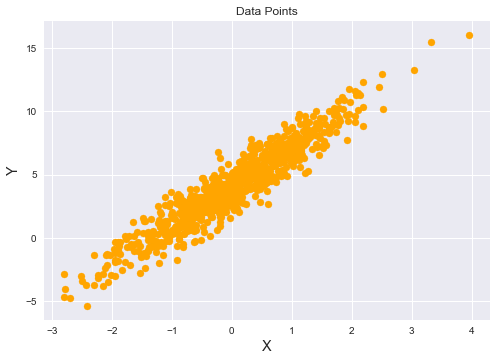

In [3]:
plt.style.use('seaborn')
plt.scatter(X, Y, c='orange')
plt.xlabel('X', fontsize='x-large')
plt.ylabel('Y', fontsize='x-large')
plt.title('Data Points')
plt.show()

## Linear Regression

In [4]:
def hypothesis(x, theta):
    y_ = theta[0] + theta[1]*x
    return y_


def gradient(X, Y, theta):
    m = X.shape[0]
    grad = np.zeros(2)
    for i in range(m):
        x = X[i]
        y_ = hypothesis(x, theta)
        y = Y[i]
        grad[0] += (y_ - y)
        grad[1] += (y_ - y)*x
    return grad/m


def error(X, Y, theta):
    m = X.shape[0]
    error = 0.0
    for i in range(m):
        y_ = hypothesis(X[i], theta)
        error += (y_ - Y[i])**2
    return (error/m)

    
def gradientDecent(X, Y, learning_rate=0.1, max_step=100):
    theta = np.zeros(2)
    error_list = []
    theta_list = []
    
    for i in range(max_step):
        grad = gradient(X, Y, theta)
        e = error(X, Y, theta)
        error_list.append(e)
        
        theta[0] = theta[0] - learning_rate*grad[0]
        theta[1] = theta[1] - learning_rate*grad[1]
        theta_list.append(theta)
    return theta, error_list, theta_list
        
        

        

In [5]:
theta, error_list, theta_list = gradientDecent(X, Y)

In [6]:
theta
theta_list[1]

array([ 4.04240036,  3.01486896])

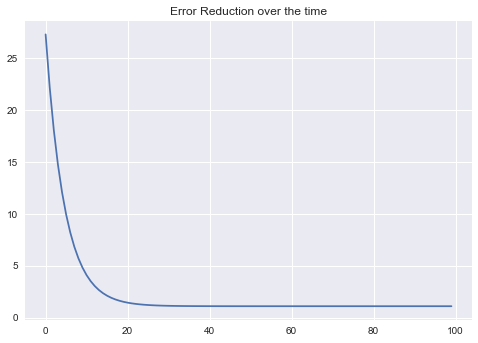

In [7]:
plt.plot(error_list)
plt.title('Error Reduction over the time')
plt.show()

## Trainnig and Prediction

In [8]:
# Predictions

y_ = hypothesis(X, theta)
print(y_[:10])

[ 8.93958877  2.19803494  2.45003174  0.80754057  6.65149096 -2.89643721
  9.30277918  1.74746131  5.00426143  3.29058136]


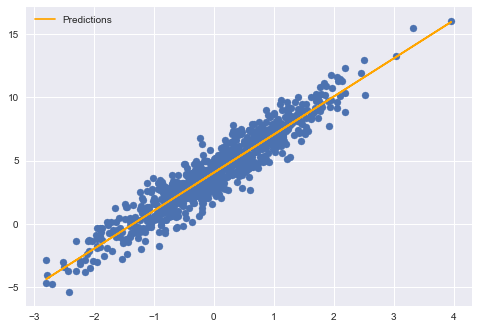

In [9]:
plt.scatter(X, Y)
plt.plot(X, y_, label='Predictions', c='orange')
plt.legend()
plt.show()

## Checking Accuracy

In [10]:
def r2_score(Y, y_):
    numerator = np.sum((Y-y_)**2)
    denomenator = np.sum((Y-Y.mean())**2)
    score = 1 - numerator/denomenator
    return score

In [11]:
print("Accuracy : ", r2_score(Y, y_))

Accuracy :  0.892341778063


## Visulizing Theta Function

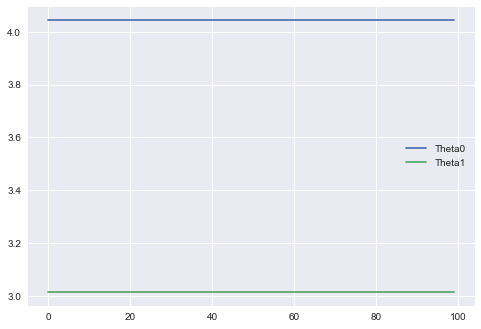

In [12]:
theta_list = np.array(theta_list)
plt.plot(theta_list[:, 0], label="Theta0")
plt.plot(theta_list[:, 1], label="Theta1")
plt.legend()